<a href="https://colab.research.google.com/github/anmollate/Data-Science/blob/main/PreProcessing%2BTraining_Pipelineipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import  pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline,make_pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score
import pickle
from sklearn.model_selection import cross_val_score

In [ ]:
df=pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/refs/heads/master/titanic.csv")

In [ ]:
df.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C


In [ ]:
df.drop(columns=['PassengerId','Name','Ticket','Cabin'],inplace=True)

In [ ]:
#train test Split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(df.drop(columns=['Survived']),df['Survived'],test_size=0.2,random_state=42)

In [ ]:
x_train.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
331,1,male,45.5,0,0,28.5000,S
733,2,male,23.0,0,0,13.0000,S
382,3,male,32.0,0,0,7.9250,S
704,3,male,26.0,1,0,7.8542,S
813,3,female,6.0,4,2,31.2750,S


In [ ]:
y_train.sample(5)

,Survived
730,1
147,0
864,0
695,0
738,0


In [ ]:
#Simple Imputer


In [ ]:
#Impute Transformer
trf1=ColumnTransformer(
    transformers=[
        ('impute_age',SimpleImputer(),[2]),
        ('impute_embarked',SimpleImputer(strategy='most_frequent'),[6])
    ],remainder='passthrough'
)

In [ ]:
#Encoding Transformers

trf2=ColumnTransformer(
    transformers=[
        ('sex_embarked_encoder',OneHotEncoder(sparse_output=False,handle_unknown='ignore'),[1,6])
    ],remainder='passthrough'
)

In [ ]:
#Scaling

trf3=ColumnTransformer(
    transformers=[
        ('scale',MinMaxScaler(),slice(0,10))
    ]
)

In [ ]:
#feature Selection

trf4=SelectKBest(score_func=chi2,k=8)

In [ ]:

trf5=DecisionTreeClassifier()

In [ ]:
#create Pipeline
pipe=Pipeline([
    ('trf1',trf1),
    ('trf2',trf2),
    ('trf3',trf3),
    ('trf4',trf4),
    ('trf5',trf5)
])

In [ ]:
#train
pipe.fit(x_train,y_train)

Pipeline(steps=[('trf1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('impute_age', SimpleImputer(),
                                                  [2]),
                                                 ('impute_embarked',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  [6])])),
                ('trf2',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('sex_embarked_encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  [1, 6])])),
                ('trf3',
                 ColumnTransformer(transformers=[('scale', MinMaxScaler(),
                                                  slice(0, 10, None))])),
                ('trf4',
                 SelectKBest(k=8,
                             score_func=<function chi2 at 0x7f90f8876980>)),
                ('trf5', DecisionTreeClassifier())])

In [ ]:
y_pred=pipe.predict(x_test)

In [ ]:
accuracy_score(y_test,y_pred)

0.6256983240223464

In [ ]:
scores=cross_val_score(pipe,df.drop(columns=['Survived']),df['Survived'],cv=10)

In [ ]:
print("Cross Validation Scores:",scores)

Cross Validation Scores: [0.6        0.56179775 0.62921348 0.65168539 0.64044944 0.62921348
 0.66292135 0.6741573  0.62921348 0.68539326]


In [ ]:
print(scores.mean())

0.6364044943820225


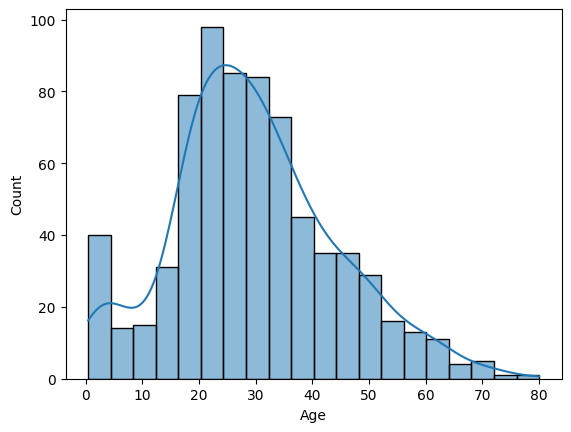

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(df['Age'].dropna(),kde=True)
plt.show()

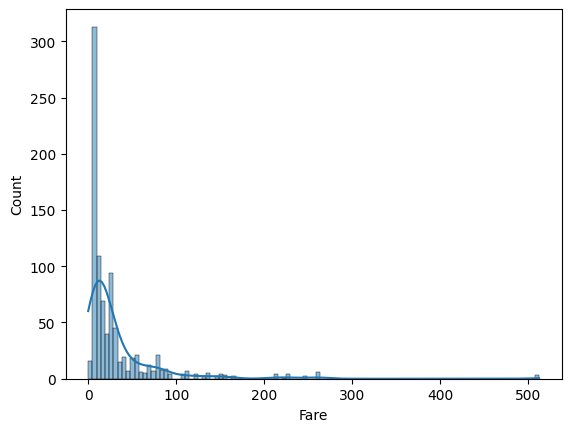

In [ ]:
sns.histplot(df['Fare'],kde=True)
plt.show()